# 2. Sales and product analysis

**Business questions:** how is revenue trending, when does it peak, which categories and products carry the business, and where is it concentrated?

Every number is read from the SQL views. Statements below are **facts or calculated metrics**; interpretation is kept separate.

In [1]:
import sys
sys.path.insert(0, "..")            # make the modules in python/ importable from this folder
import pandas as pd
import matplotlib.pyplot as plt
import visualization as viz
from data_extraction import get_view
pd.set_option("display.width", 160, "display.max_columns", 20, "display.float_format", "{:,.1f}".format)
%matplotlib inline

In [2]:
import sales_analysis as sa, product_analysis as pa
from kpis import growth_table, yearly_summary
monthly = get_view('vw_monthly_sales')
cats = get_view('vw_category_performance')
products = get_view('vw_product_performance')
orders = get_view('vw_orders')

## Revenue by year
*Calculated metric:* net revenue excludes GST; growth is year over year.

In [3]:
yearly_summary(monthly)

,year,orders,net_revenue,gross_profit,margin_pct,yoy_growth_pct
0,2023,16317,"45,426,182.9","10,451,082.0",23.0,NaN
1,2024,18096,"50,899,247.4","11,769,918.9",23.1,12.0
2,2025,19847,"56,201,670.5","13,427,993.3",23.9,10.4


## Monthly trend, growth and moving average

In [4]:
growth_table(monthly).tail(12)

,month,net_revenue,orders,gross_profit,mom_growth_pct,yoy_growth_pct,moving_avg_3m,running_total
24,2025-01-01,"3,441,476.2",1314,"842,556.8",-32.1,7.0,"4,695,075.6","99,766,906.5"
25,2025-02-01,"3,594,943.9",1322,"861,599.9",4.5,10.5,"4,034,591.5","103,361,850.4"
26,2025-03-01,"4,669,778.1",1500,"1,120,346.1",29.9,25.1,"3,902,066.1","108,031,628.6"
27,2025-04-01,"4,635,974.0",1571,"1,067,094.1",-0.7,10.4,"4,300,232.0","112,667,602.5"
28,2025-05-01,"4,990,200.6",1590,"1,165,779.4",7.6,33.3,"4,765,317.6","117,657,803.1"
29,2025-06-01,"3,741,632.2",1444,"932,189.2",-25.0,4.2,"4,455,935.6","121,399,435.3"
30,2025-07-01,"3,960,916.0",1451,"940,876.1",5.9,8.4,"4,230,916.3","125,360,351.3"
31,2025-08-01,"4,485,930.5",1534,"1,101,202.3",13.3,11.8,"4,062,826.2","129,846,281.8"
32,2025-09-01,"4,742,421.8",1690,"1,209,701.4",5.7,-2.0,"4,396,422.8","134,588,703.6"
33,2025-10-01,"6,865,660.3",2337,"1,544,791.7",44.8,14.2,"5,364,670.9","141,454,363.9"


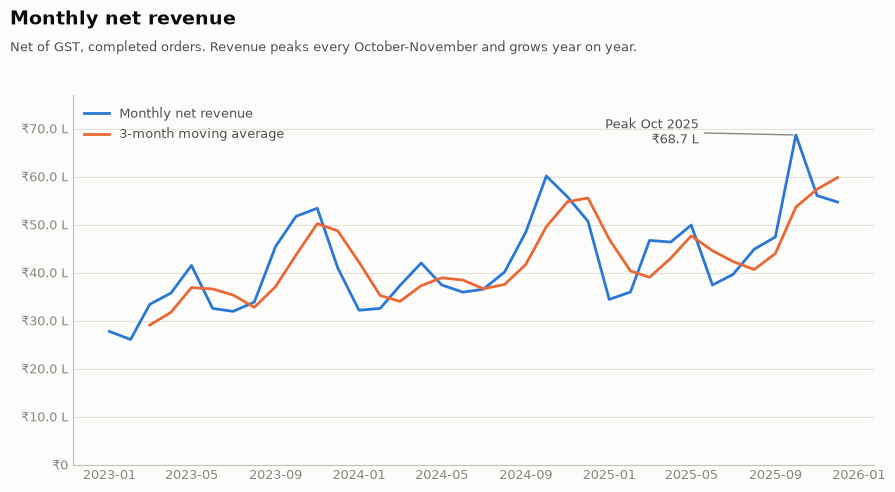

In [5]:
viz.monthly_revenue_trend(monthly); plt.show()

## Seasonality
Each calendar month relative to its own year's average (100 = a typical month). Dividing by the yearly average removes the growth trend.

In [6]:
sa.seasonality_index(monthly)

,month_number,month,seasonality_index
0,1,Jan,74.2
1,2,Feb,74.1
2,3,Mar,92.0
3,4,Apr,97.5
4,5,May,101.5
5,6,Jun,83.5
6,7,Jul,85.0
7,8,Aug,93.3
8,9,Sep,111.8
9,10,Oct,141.6


## Channel mix

In [7]:
sa.channel_mix(monthly)

,year,orders,online_orders,online_share_pct
0,2023,16317,1775,10.9
1,2024,18096,2760,15.3
2,2025,19847,3963,20.0


## Categories
*Observation to check:* Footwear shows a very large jump in 2025. The next cell shows what drives it.

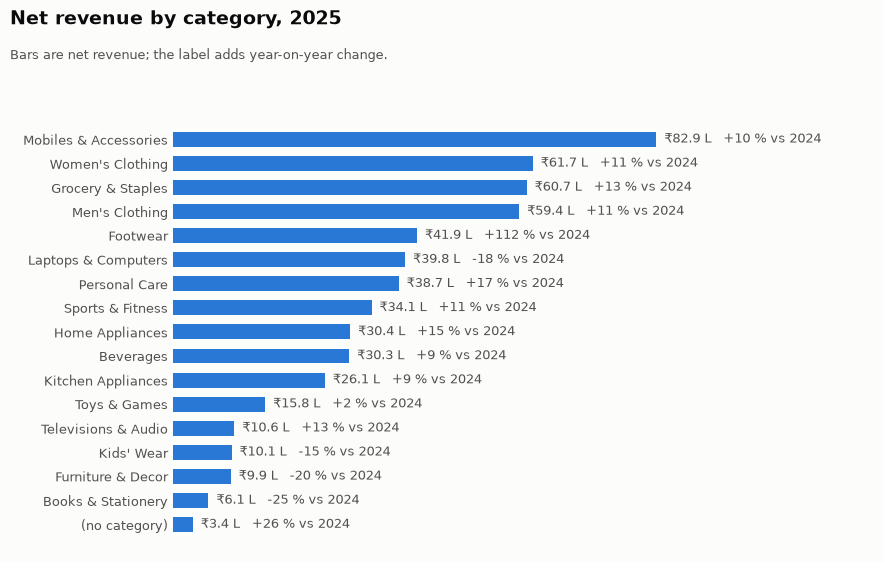

year,category_name,2023,2024,2025,growth_2024_pct,growth_2025_pct,trend
0,Books & Stationery,"911,848.5","820,328.0","611,806.3",-10.0,-25.4,Declining two years in a row
1,Furniture & Decor,"1,308,935.6","1,239,952.4","993,809.7",-5.3,-19.9,Declining two years in a row
2,Laptops & Computers,"4,449,277.2","4,861,147.9","3,984,220.0",9.3,-18.0,Declined in 2025
3,Kids' Wear,"1,187,128.9","1,186,257.0","1,007,567.3",-0.1,-15.1,Declining two years in a row
4,Toys & Games,"1,792,531.9","1,555,534.2","1,584,408.2",-13.2,1.9,Growing / stable
5,Beverages,"2,435,115.2","2,784,049.1","3,025,578.6",14.3,8.7,Growing / stable
6,Kitchen Appliances,"1,976,050.8","2,395,521.7","2,608,588.1",21.2,8.9,Growing / stable
7,Mobiles & Accessories,"5,739,234.1","7,556,884.4","8,292,079.7",31.7,9.7,Growing / stable
8,Women's Clothing,"4,726,710.3","5,569,292.7","6,173,836.4",17.8,10.9,Growing / stable
9,Men's Clothing,"4,777,815.3","5,344,754.2","5,938,995.1",11.9,11.1,Growing / stable


In [8]:
viz.category_revenue(cats); plt.show()
pa.category_trends(cats)

In [9]:
# Which products drive the Footwear increase? (a product launched in March 2025 explains most of it)
from data_extraction import get_query
f = get_query("""SELECT product_name, order_year, SUM(net_revenue) AS revenue FROM vw_sales_lines JOIN products USING (product_id)
                  WHERE category_name = 'Footwear' GROUP BY 1, 2""").pivot_table(index='product_name', columns='order_year', values='revenue').fillna(0)
f['change_2025_vs_2024'] = f[2025] - f[2024]
f.sort_values('change_2025_vs_2024', ascending=False).head(5)

order_year,2023,2024,2025,change_2025_vs_2024
product_name,,,,
Pacer Ankle Boots UK 6,0.0,0.0,"1,534,046.5","1,534,046.5"
Kolhapuri Co Kids School Shoes Brown,0.0,"168,459.6","590,430.5","421,970.9"
Pacer Formal Shoes Brown,0.0,0.0,"126,636.7","126,636.7"
Kolhapuri Co Casual Sneakers UK 6,"144,895.9","147,427.3","250,541.8","103,114.5"
Walkwell Formal Shoes UK 9,"30,640.7","38,819.6","83,770.7","44,951.0"


## Products: top sellers, Pareto and concentration

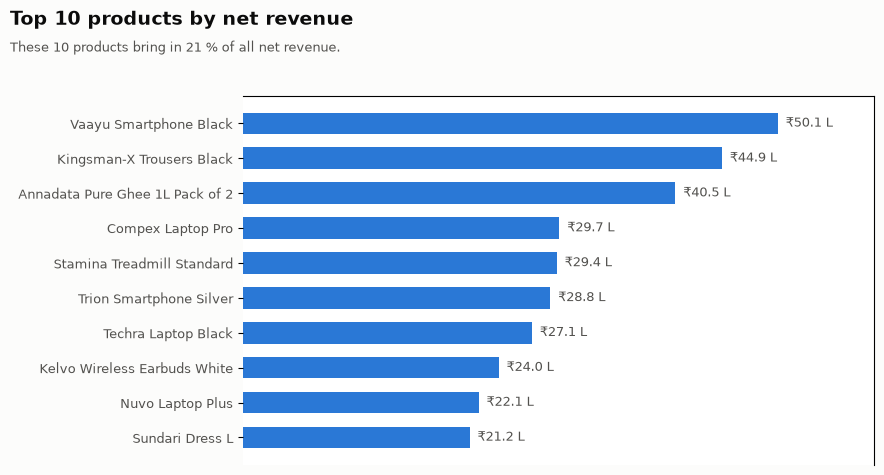

,abc_class,products,net_revenue,product_share_pct,revenue_share_pct
0,A,216,"122,105,334.4",35.4,80.1
1,B,191,"22,847,609.6",31.3,15.0
2,C,203,"7,574,157.0",33.3,5.0


In [10]:
viz.top_products(products); plt.show()
pa.abc_summary(products)

In [11]:
pa.concentration(products)

{'products_sold': 610,
 'top_10_pct_of_revenue': 20.8,
 'top_50_pct_of_revenue': 46.0,
 'top_20pct_products_pct_of_revenue': 65.6,
 'herfindahl_index': 0.0074}

## High-return products
Flagged only when a product has a meaningful volume **and** returns at 2.5x or more of its category rate. A flag is a prompt to investigate, not a conclusion.

In [12]:
pa.high_return_products(products)

,product_name,category,units_sold,units_returned,return_rate_pct,category_rate_pct,times_category_rate
0,Annadata Wheat Atta 10kg Pack of 1,Grocery & Staples,415,8,1.9,0.3,6.8
1,Gudda T-Shirt Set 2-3Y,Kids' Wear,180,29,16.1,3.6,4.5
2,Ace Sports Yoga Mat Black,Sports & Fitness,88,9,10.2,2.4,4.3
3,Tropica Soft Drink 6-Pack Zero Sugar,Beverages,3344,54,1.6,0.4,4.0
4,Munchkin Shorts Blue,Kids' Wear,106,10,9.4,3.6,2.6


## Order-value distribution

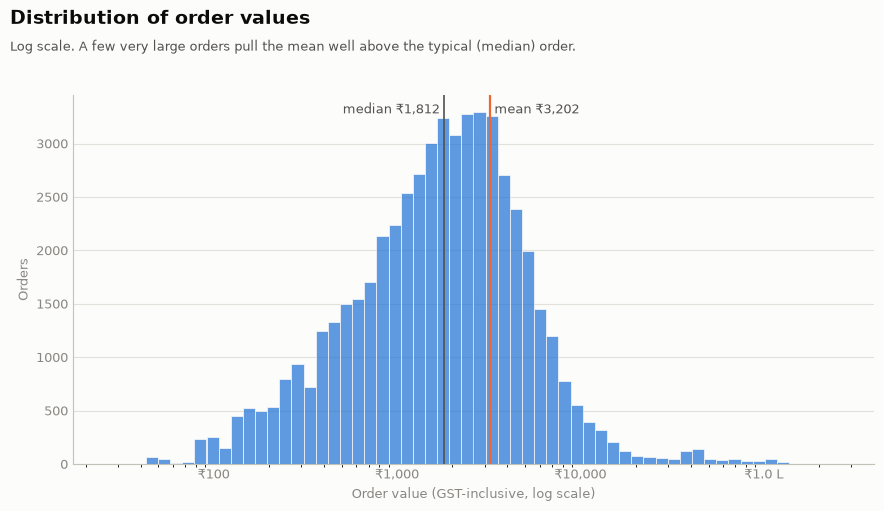

{'mean': np.float64(3201.758102100995),
 'median': np.float64(1812.0),
 'p25': np.float64(828.0),
 'p75': np.float64(3422.0625),
 'p90': np.float64(5816.068999999999),
 'p99': np.float64(34835.834699999985),
 'max': np.float64(252622.0),
 'iqr_fence': np.float64(7313.15625)}

In [13]:
viz.order_value_distribution(orders); plt.show()
sa.order_value_distribution(orders)